In [1]:
%load_ext autoreload
%autoreload 2
#import qRegNN_NFs as qrnn
#from trainingTools_QR import NFTrainer
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
from trainingTools import NFTrainer
import qRegNN_NFs as qrnn

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
test = hf.loadData("BKG",["dEta","jet1_eta","jet2_eta"],nMax=10000,mode='all',
                    dEta_cut=-1,sideband=True)

  0%|          | 0/80 [00:00<?, ?it/s]


In [20]:
b = test[:,0]
a = test[:,1]-test[:,2]

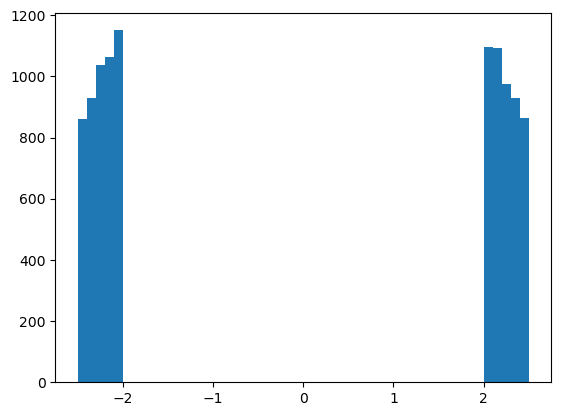

In [23]:
h = plt.hist(a,bins=50)

# Train models

In [2]:
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf']
rangeScale = 5

Loading train sample


  4%|▍         | 3/80 [00:05<02:15,  1.75s/it]


100000 training events
Training flow BKG
Iteration 10 Complete
Loss:  3.5188064575195312
Iteration 20 Complete
Loss:  3.277946710586548
Iteration 30 Complete
Loss:  3.1803526878356934
Iteration 40 Complete
Loss:  3.1416354179382324
Iteration 50 Complete
Loss:  3.111236333847046
Iteration 60 Complete
Loss:  3.0936319828033447
Iteration 70 Complete
Loss:  3.1879491806030273
Loading test sample


 38%|███▊      | 30/80 [00:40<01:06,  1.34s/it]


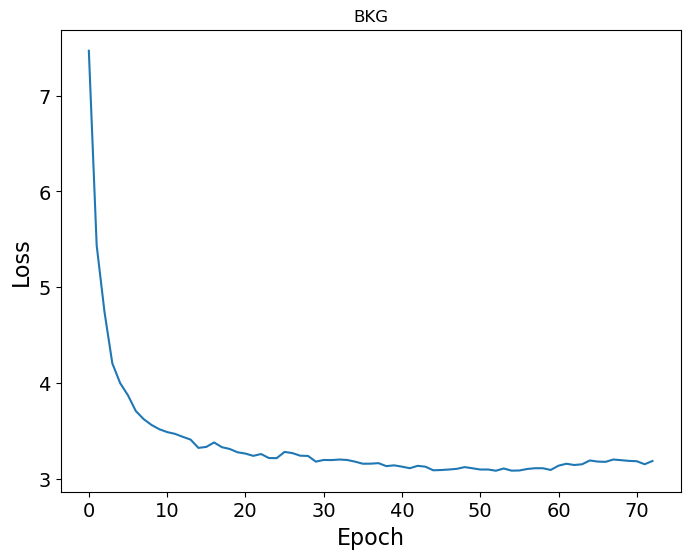

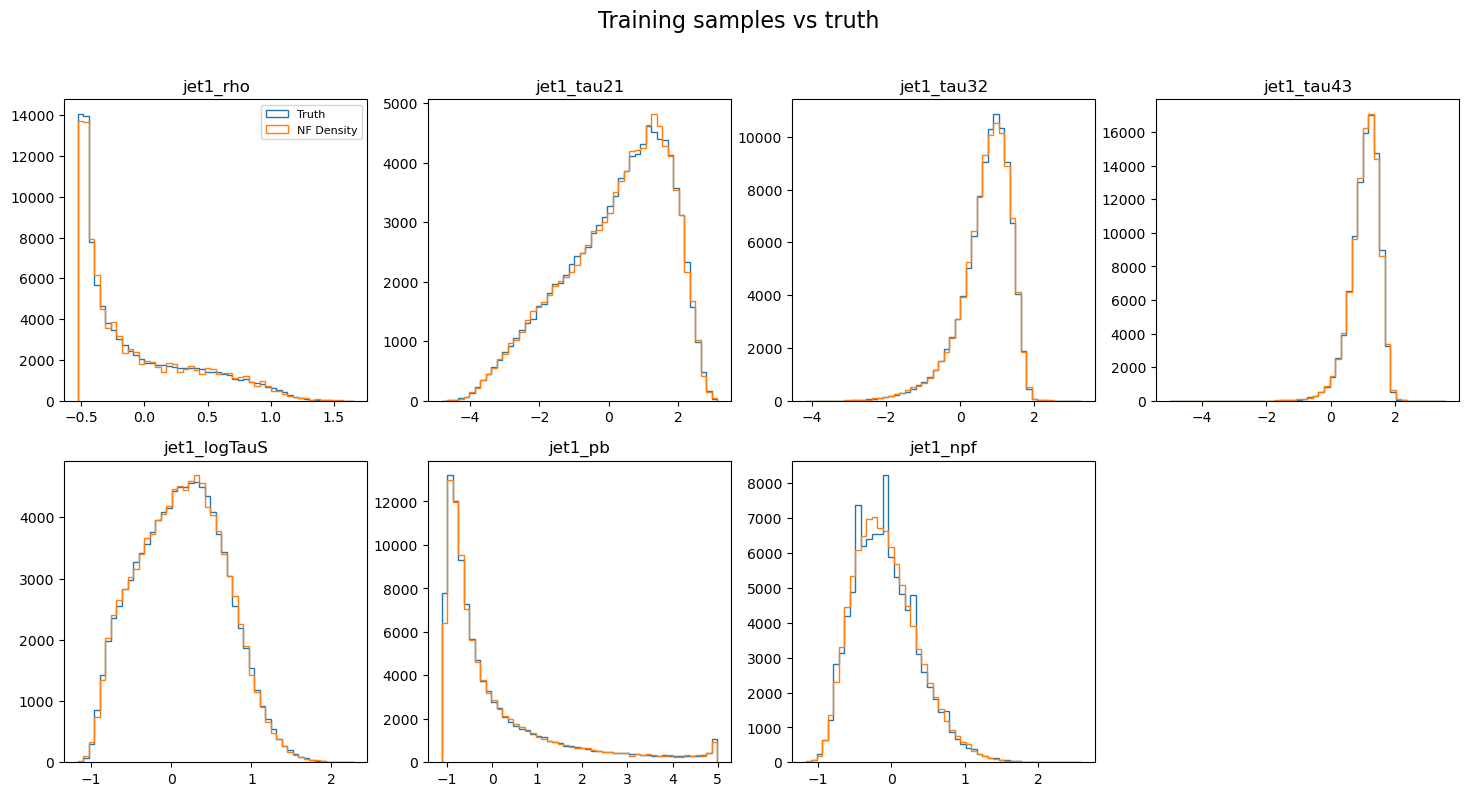

Loading test sample


 38%|███▊      | 30/80 [00:02<00:04, 12.32it/s]


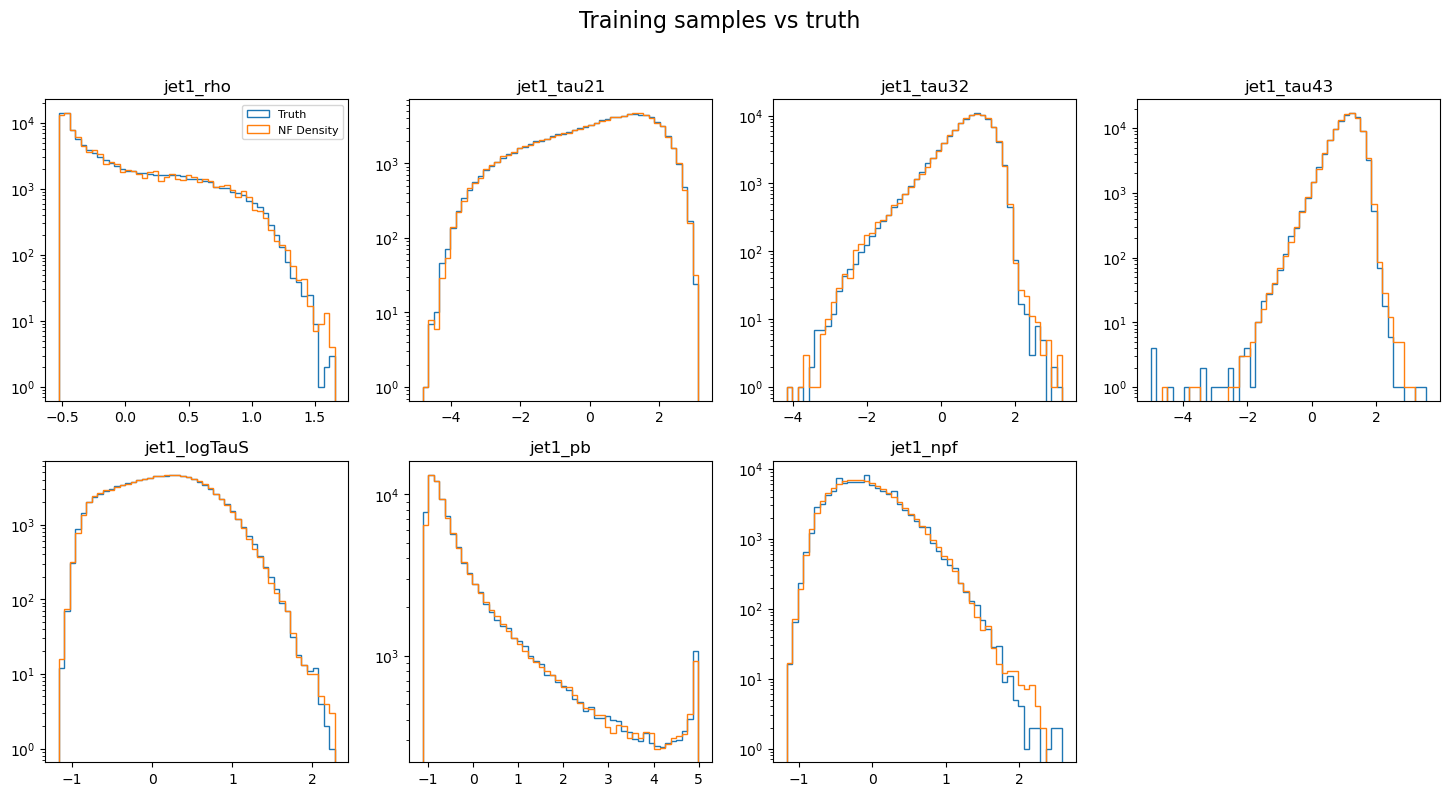

In [3]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":6,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "BKG"
reference = "BKG"
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    sideband=True,
                   minmax=True,rangeScale=rangeScale)
#trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
#              print_interval=10,T_max=50,eta_min=1e-5)
trainer.train()
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)
flow_bkg = trainer.get_model()

Loading train sample


  0%|          | 0/40 [00:03<?, ?it/s]


100000 training events
Training flow DATA
Iteration 10 Complete
Loss:  3.9451534748077393
Iteration 20 Complete
Loss:  3.7410709857940674
Iteration 30 Complete
Loss:  3.600095272064209
Iteration 40 Complete
Loss:  3.5705058574676514
Iteration 50 Complete
Loss:  3.5415565967559814
Iteration 60 Complete
Loss:  3.521854877471924
Iteration 70 Complete
Loss:  3.630399227142334
Loading test sample


 12%|█▎        | 5/40 [00:18<02:09,  3.71s/it]


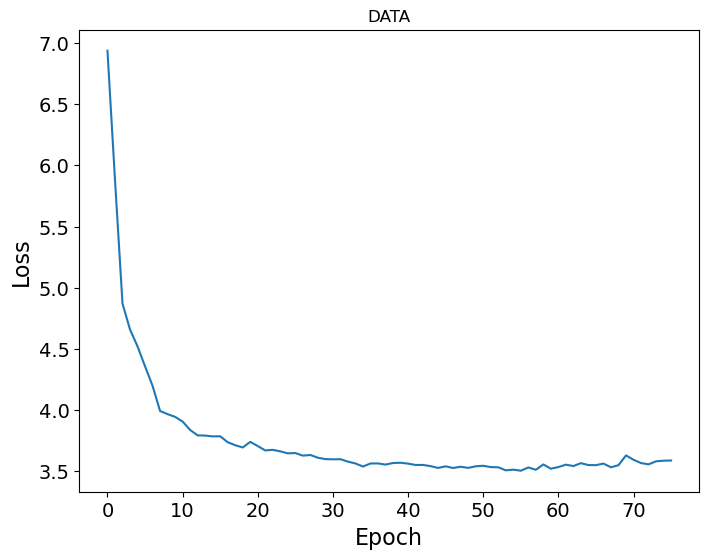

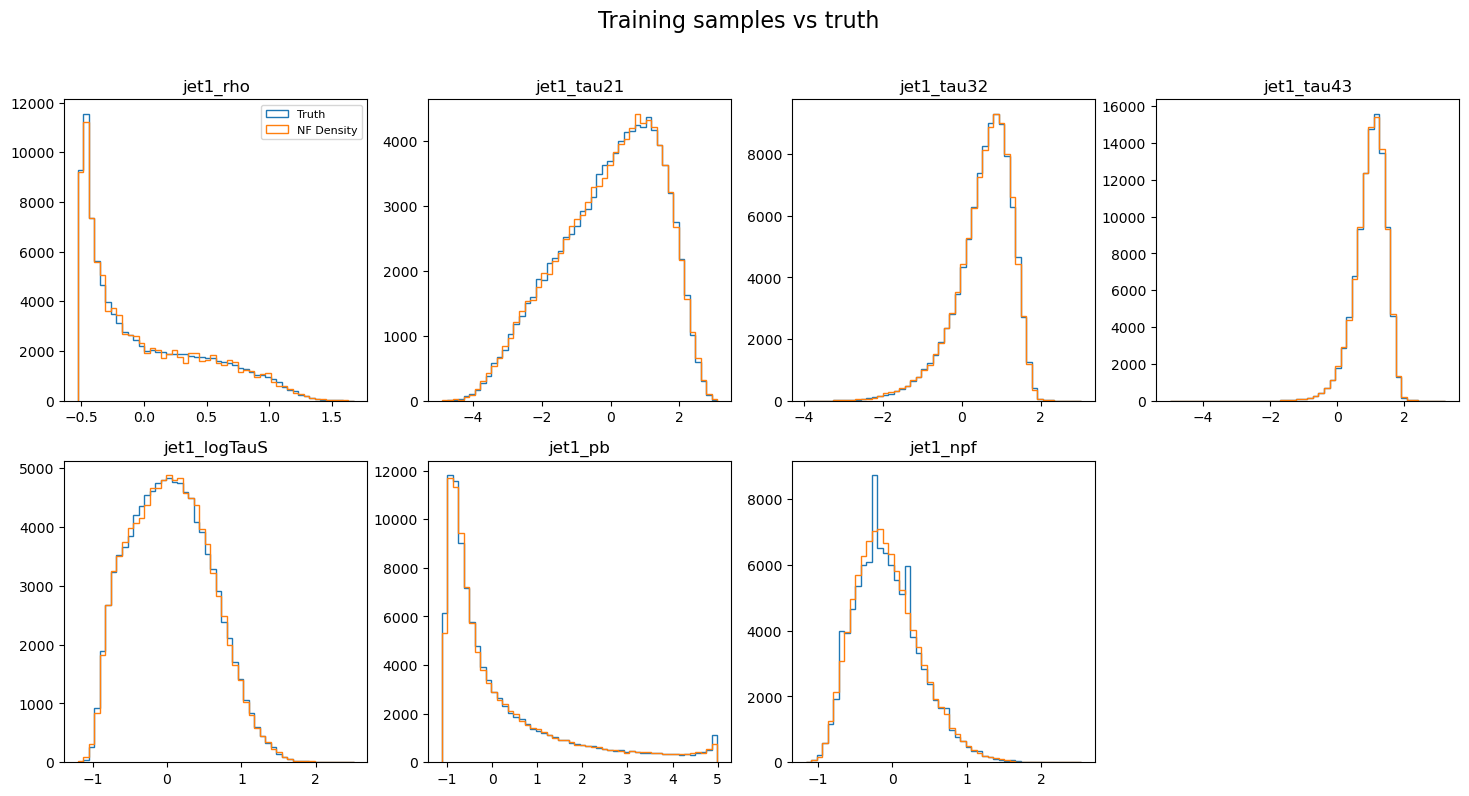

Loading test sample


 12%|█▎        | 5/40 [00:03<00:21,  1.59it/s]


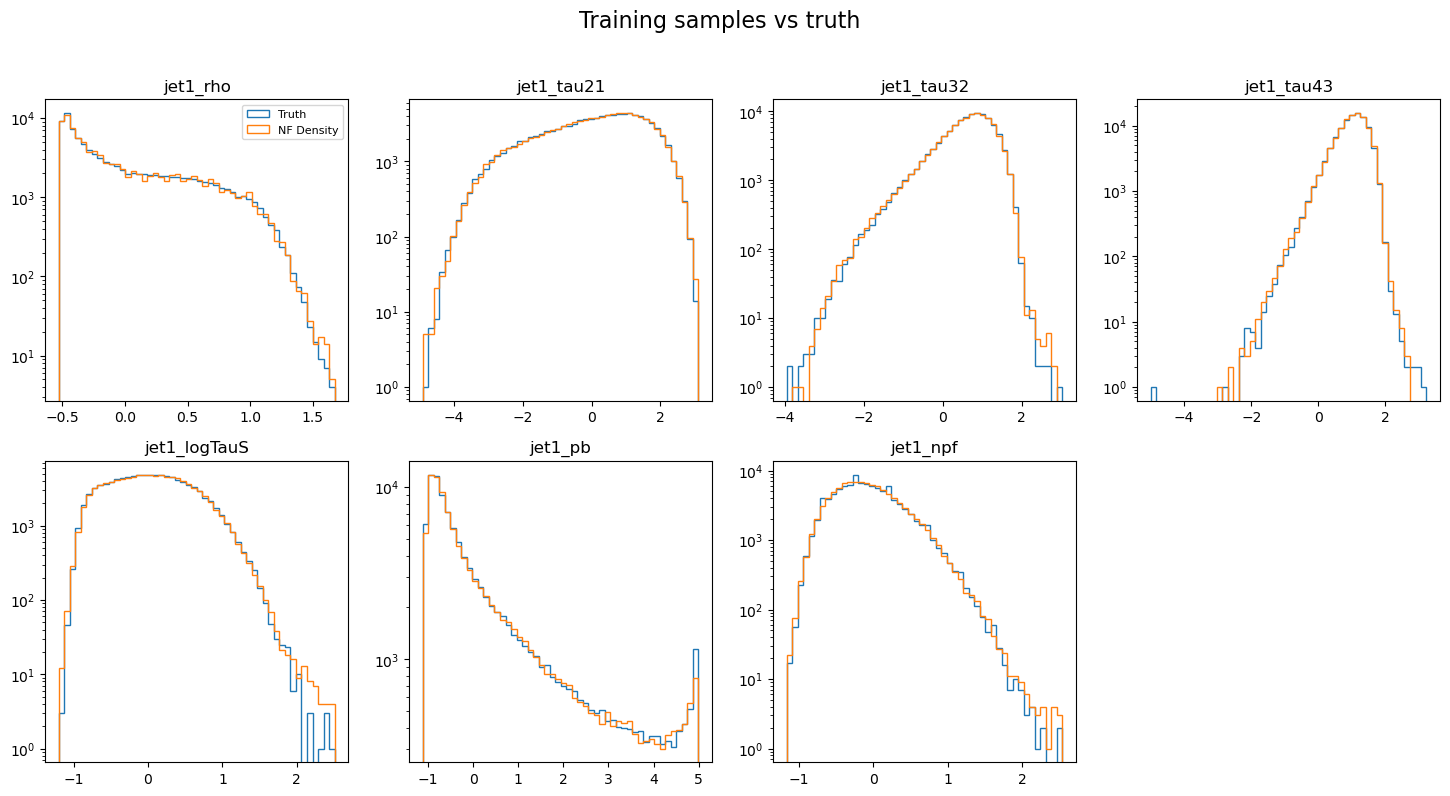

In [4]:
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":6,"hidden_features":160,
             "num_layers":6,"num_bins":80,"num_blocks_per_layer":5,"tails":"linear"}
sample = "DATA"
reference = "BKG"
nTrain = 100000
trainer = NFTrainer(sample,reference,variables,
                    nTrain=nTrain,NF_kwargs=NF_kwargs,
                    sideband=True,
                   minmax=True,rangeScale=rangeScale)
#trainer.train(bs=10000,n_epoch=200,patience=20,learning_rate=1e-4,
#              print_interval=10,T_max=50,eta_min=1e-5)
trainer.train()
trainer.plotDensity(100000)
trainer.plotDensity(100000,log=True)
flow_data = trainer.get_model()

In [5]:
import torch
import torch.nn as nn
import json
from trainingTools import loadData
device = torch.device("cuda:0")
nevents = 100000
data = loadData("DATA",variables,nevents,dEta_cut=-1,sideband=True,mode="test",mean_reference="BKG",minmax=True,rangeScale=rangeScale)
bkg = loadData("BKG",variables,nevents,dEta_cut=-1,sideband=True,mode="test",mean_reference="BKG",minmax=True,rangeScale=rangeScale)

Loading test sample


 12%|█▎        | 5/40 [00:03<00:22,  1.56it/s]


Loading test sample


 38%|███▊      | 30/80 [00:02<00:04, 11.90it/s]


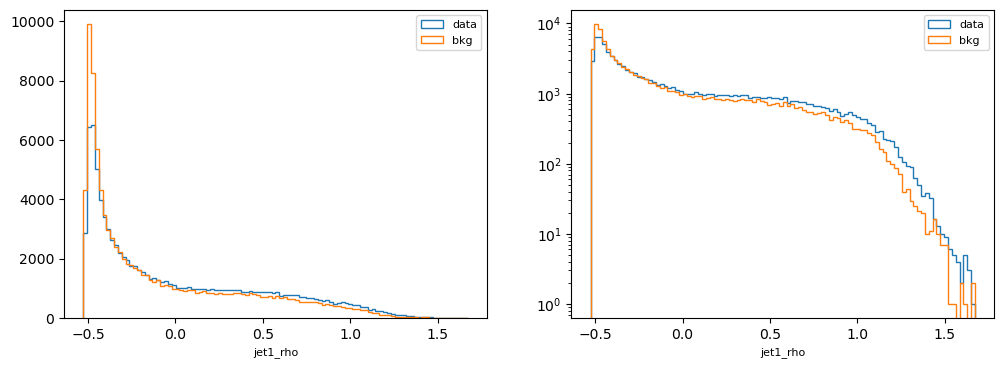

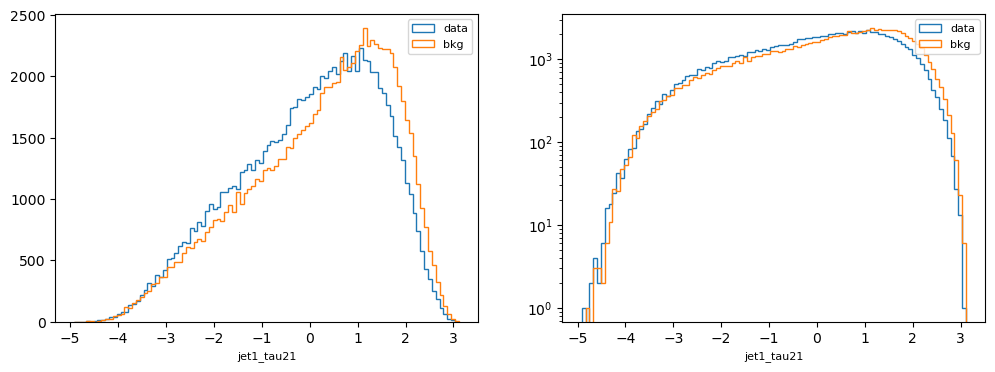

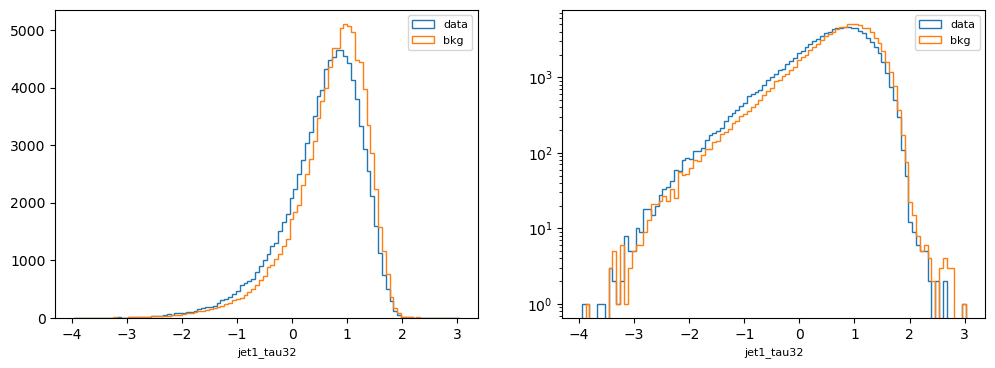

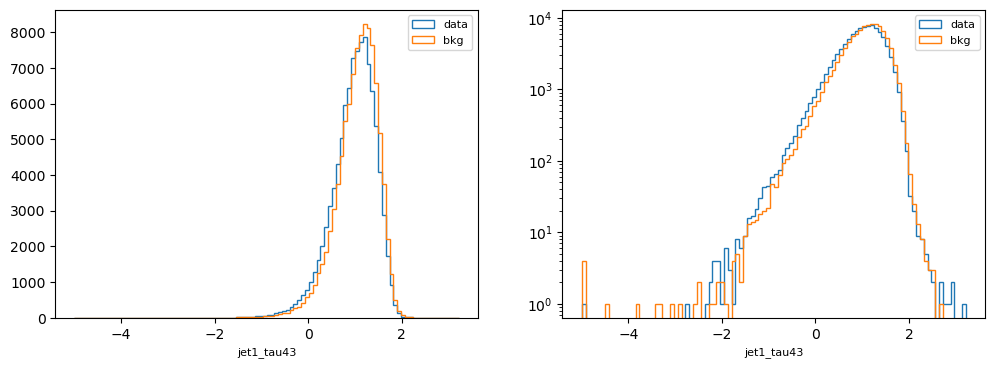

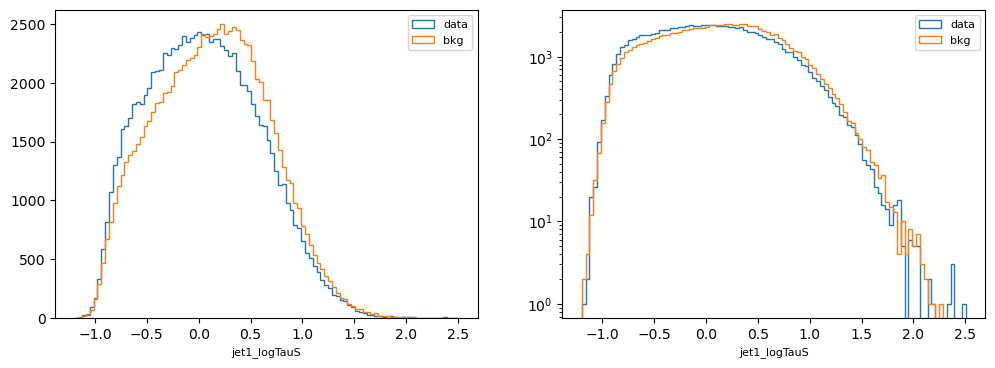

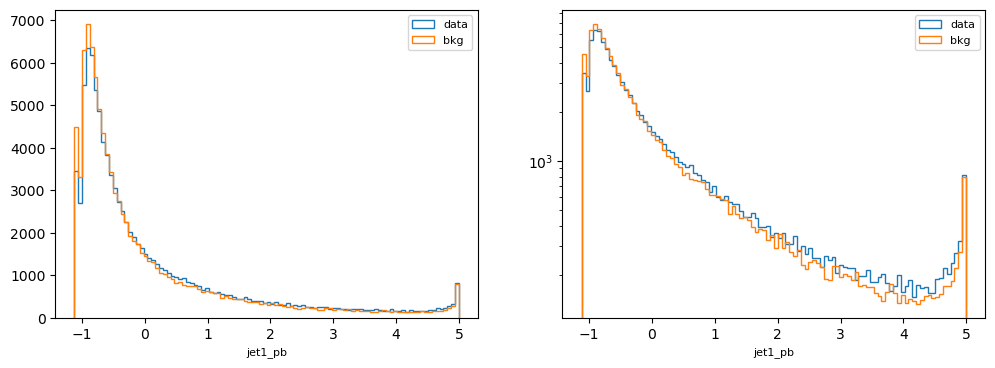

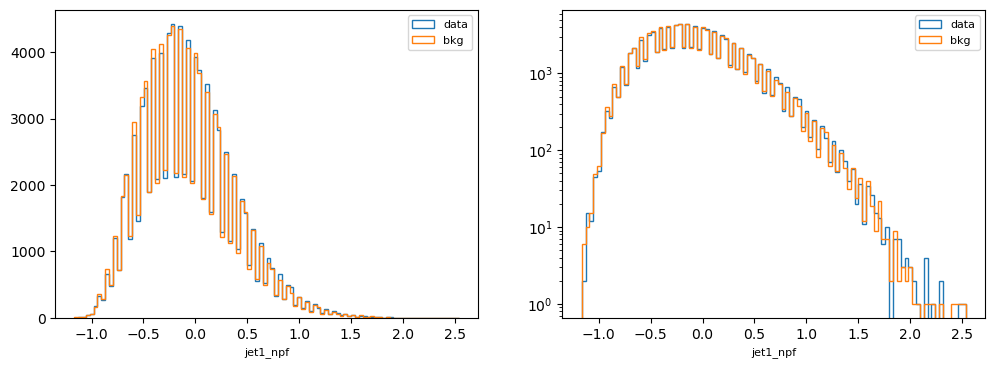

In [6]:
#bins = np.linspace(-5,5,100)
for i,v in enumerate(variables):
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    h1,bins,_ = plt.hist(data[:,i],bins=100,histtype='step',label='data')
    h1 = plt.hist(bkg[:,i],bins=bins,histtype='step',label='bkg')
    plt.legend()
    plt.xlabel(v)
    plt.subplot(122)
    h1 = plt.hist(data[:,i],bins=bins,histtype='step',label='data')
    h1 = plt.hist(bkg[:,i],bins=bins,histtype='step',label='bkg')
    plt.legend()
    plt.yscale('log')
    plt.xlabel(v)

In [7]:
with torch.no_grad():
    pD = flow_data.log_prob(torch.tensor(bkg,dtype=torch.float32).to(device))[0].detach().cpu().numpy()
    pB = flow_bkg.log_prob(torch.tensor(bkg,dtype=torch.float32).to(device))[0].detach().cpu().numpy()

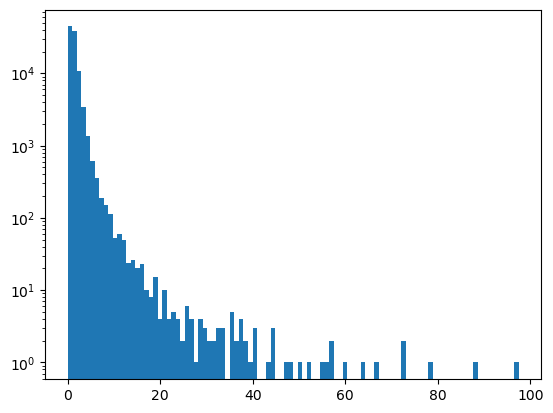

In [12]:
wgt = np.exp(pB-pD)
wgt[(wgt>100)]=1
h=plt.hist(wgt,bins=100)
plt.yscale('log')

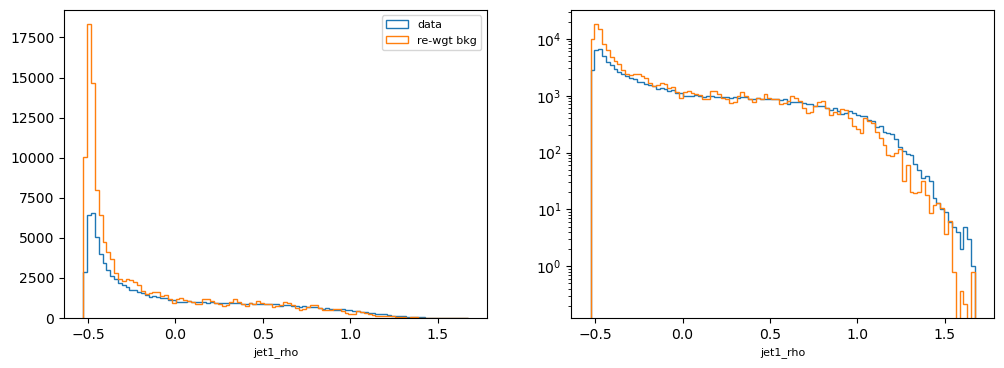

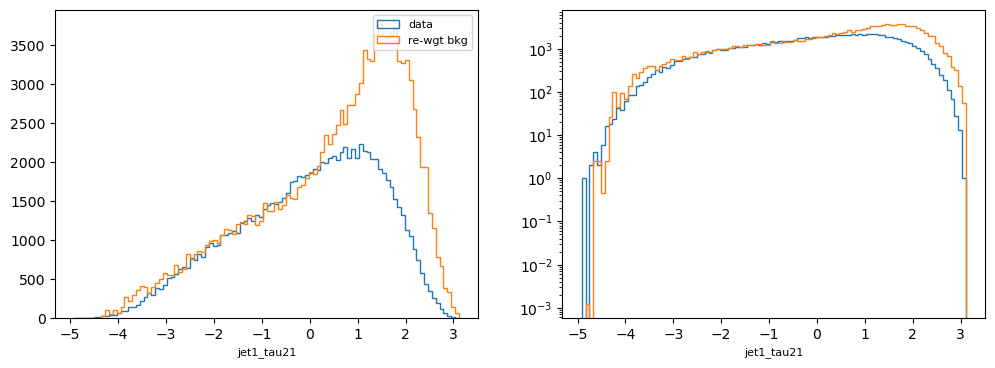

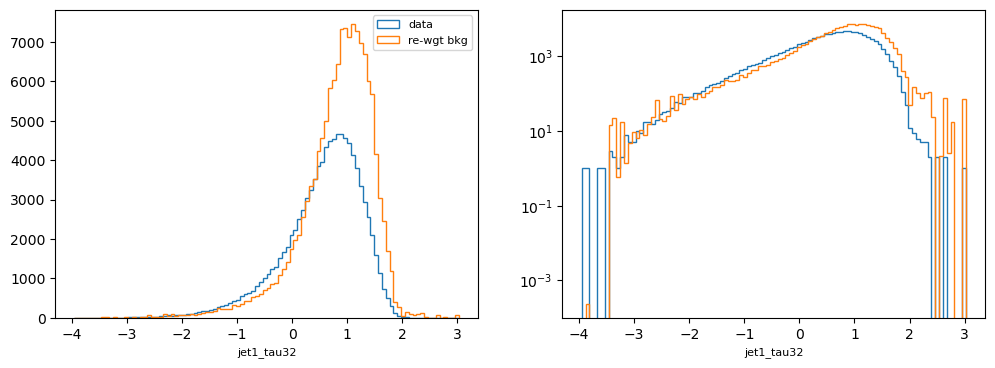

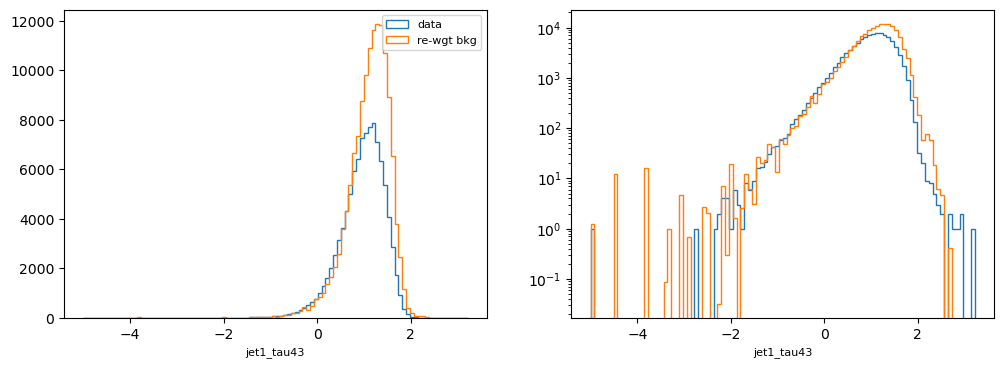

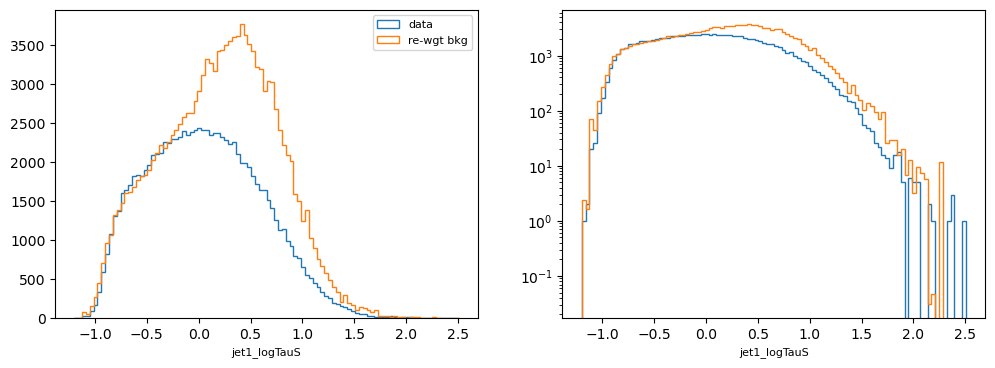

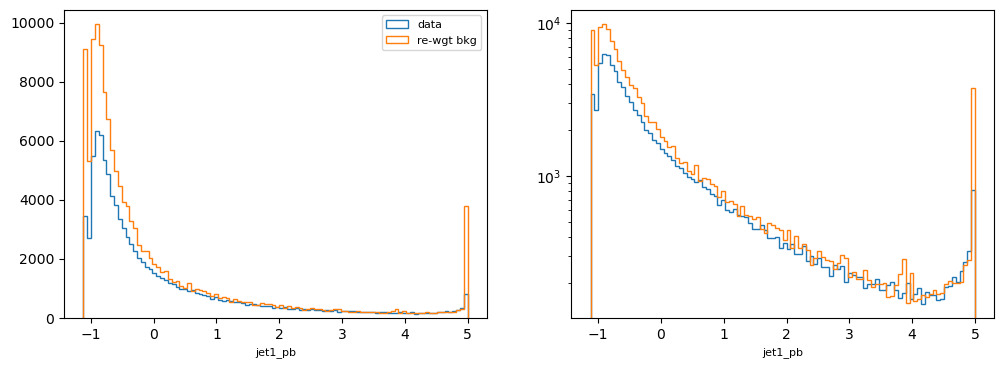

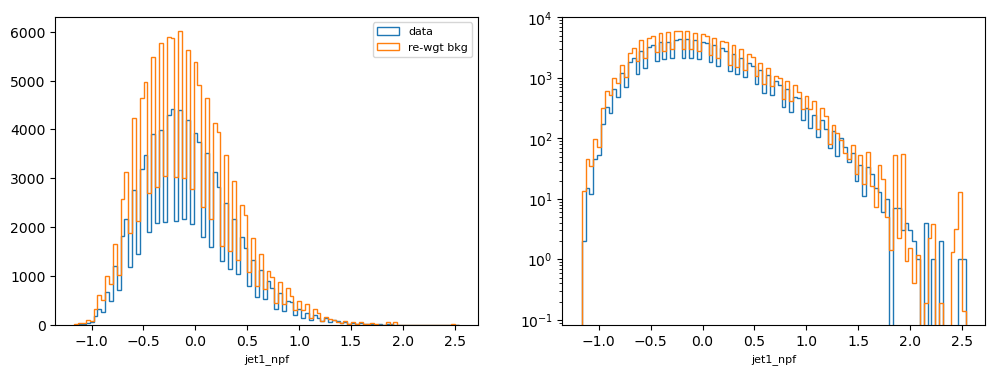

In [14]:
#bins = np.linspace(-5,5,100)
for i,v in enumerate(variables):
    plt.figure(figsize=(12,4))
    plt.subplot(121)
    h1,bins,_ = plt.hist(data[:,i],bins=100,histtype='step',label='data')
    h1 = plt.hist(bkg[:,i],bins=bins,histtype='step',weights=wgt,label='re-wgt bkg')
    plt.xlabel(v)
    plt.legend()
    plt.subplot(122)
    h1 = plt.hist(data[:,i],bins=bins,histtype='step',label='data')
    h1 = plt.hist(bkg[:,i],bins=bins,histtype='step',weights=wgt,label='re-wgt bkg')
    plt.yscale('log')
    plt.xlabel(v)

# With framework

In [16]:
#controlVars = ['signed_dEta',"jet1_npf"]
#fitVars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb']
controlVars = []
fitVars = ['jet1_rho']
NF_kwargs = {"flow_type":"NSRATQUAD","tail_bound":3.5,"hidden_features":400,
             "num_layers":1,"num_bins":200,"num_blocks_per_layer":5,"tails":"linear"}
rangeScale = 3
trainer = qrnn.chainedNFTrainer(controlVars,fitVars,nTrain=100000,nTest=100000,NF_kwargs=NF_kwargs,outDir="NF_models/",
                 dEta_cut=-1,sideband=True,rangeScale=rangeScale,minmax=True,mean_reference="BKG")

Loading train sample


  2%|▎         | 1/40 [00:01<01:08,  1.77s/it]


Loading train sample


  5%|▌         | 4/80 [00:01<00:20,  3.69it/s]


Loading test sample


 15%|█▌        | 6/40 [00:10<01:01,  1.81s/it]


Loading test sample


 39%|███▉      | 31/80 [00:12<00:19,  2.52it/s]


RUNNING TRAININGS
Training flow bkgFlow_step0_jet1_rho
Iteration 10 Complete
Loss:  0.5320737361907959
Iteration 20 Complete
Loss:  0.48256736993789673
Iteration 30 Complete
Loss:  0.49119460582733154
Iteration 40 Complete
Loss:  0.47367724776268005
Iteration 50 Complete
Loss:  0.4702076017856598
Iteration 60 Complete
Loss:  0.47985750436782837
Training flow dataFlow_step0_jet1_rho
Iteration 10 Complete
Loss:  0.6671958565711975
Iteration 20 Complete
Loss:  0.6724721789360046
Iteration 30 Complete
Loss:  0.6659640669822693
Iteration 40 Complete
Loss:  0.6594294905662537
Iteration 50 Complete
Loss:  0.650077223777771
Iteration 60 Complete
Loss:  0.6647613644599915
Iteration 70 Complete
Loss:  0.653687596321106
Iteration 80 Complete
Loss:  0.6550299525260925
CORRECTING BKG


  0%|          | 0/11 [00:00<?, ?it/s]/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs.py:356: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  context = torch.tensor(bkg_train_context[i],dtype=torch.float32,device=device)
  0%|          | 0/11 [00:00<?, ?it/s]/home/sambt/CASE_final/CASE_QUAK_final/commonTools/qRegNN_NFs.py:383: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  context = torch.tensor(bkg_test_context[i],dtype=torch.float32,device=device)
100%|██████████| 11/11 [00:00<00:00, 17.25it/s]


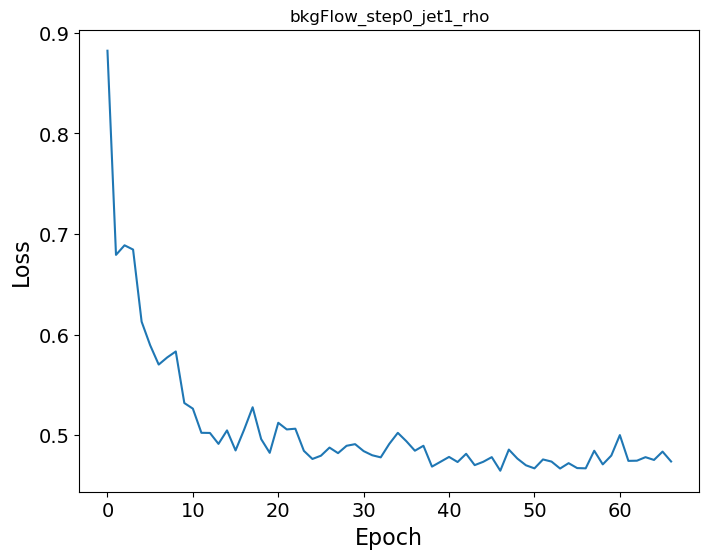

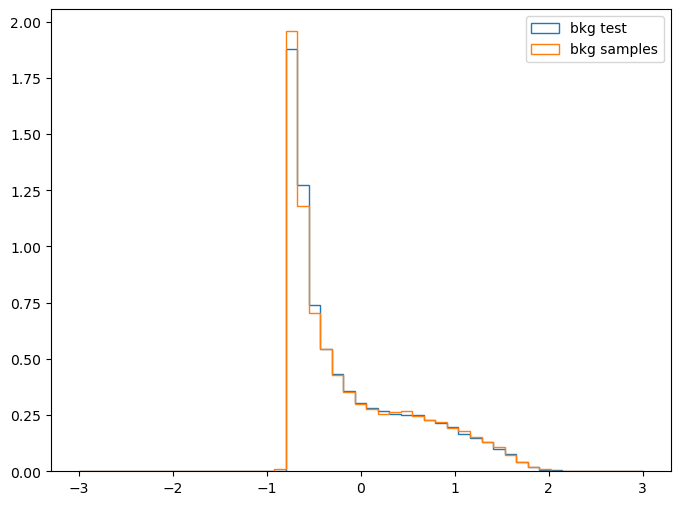

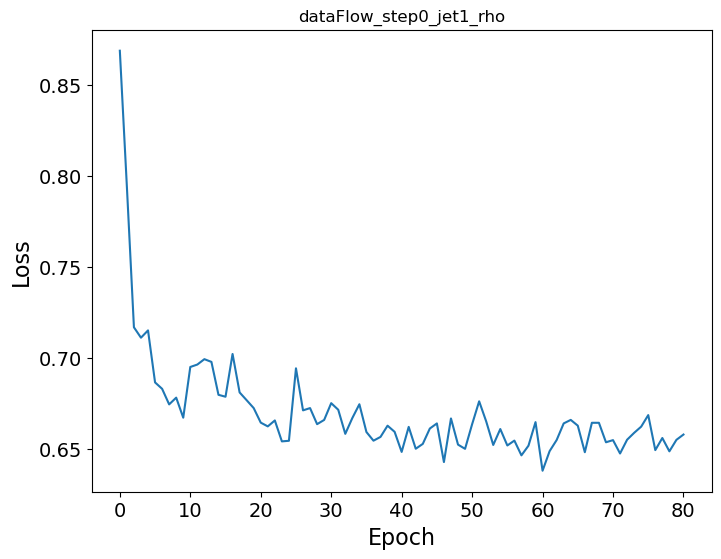

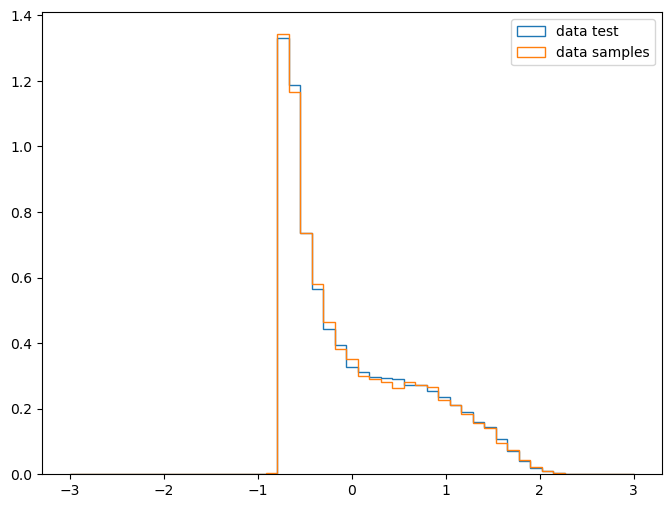

In [17]:
trainer.runAll(patience=20,learning_rate=5e-4)

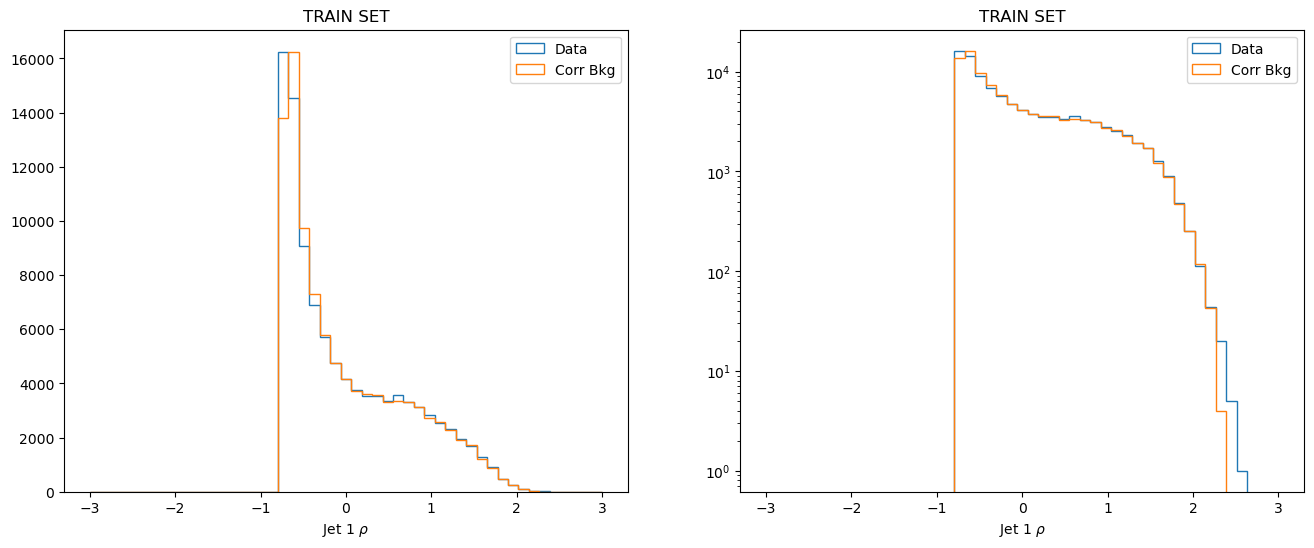

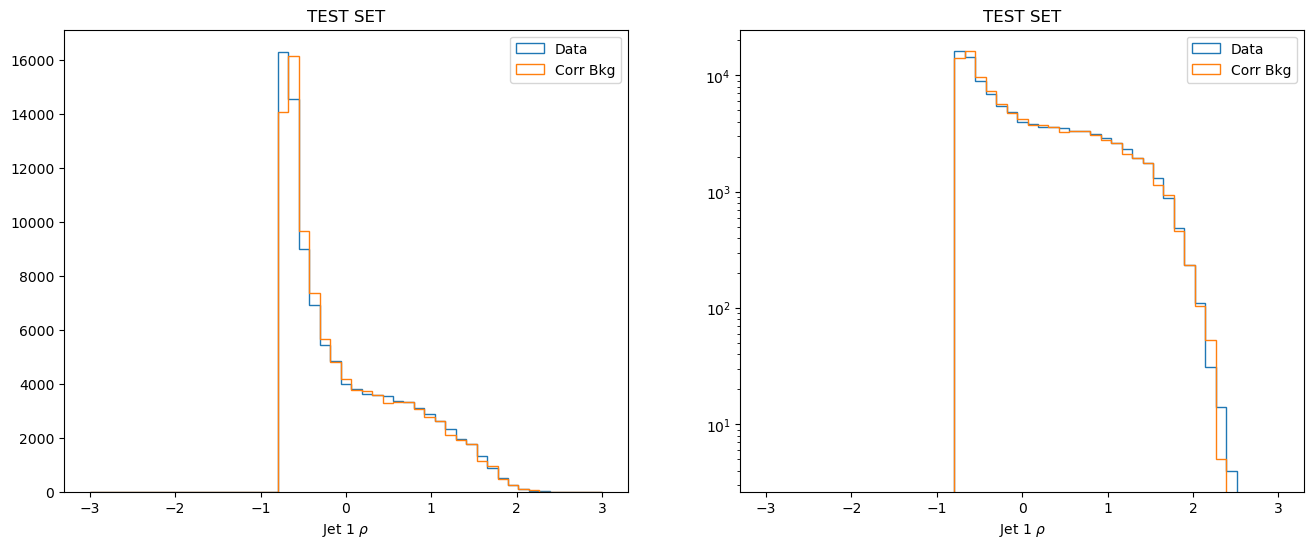

In [18]:
trainer.plotAll(np.linspace(-3,3,50))

In [19]:
data,bkg_corr,variables = trainer.correctFull(n_per=50000,nevts=1000000)

Loading all sample


  2%|▎         | 1/40 [00:00<00:09,  4.30it/s]


Loading all sample


100%|██████████| 21/21 [00:01<00:00, 15.92it/s]


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: invalid value encountered in true_divide
  # This is added back by InteractiveShellApp.init_path()
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:26: RuntimeWarning: invalid value encountered in true_divide


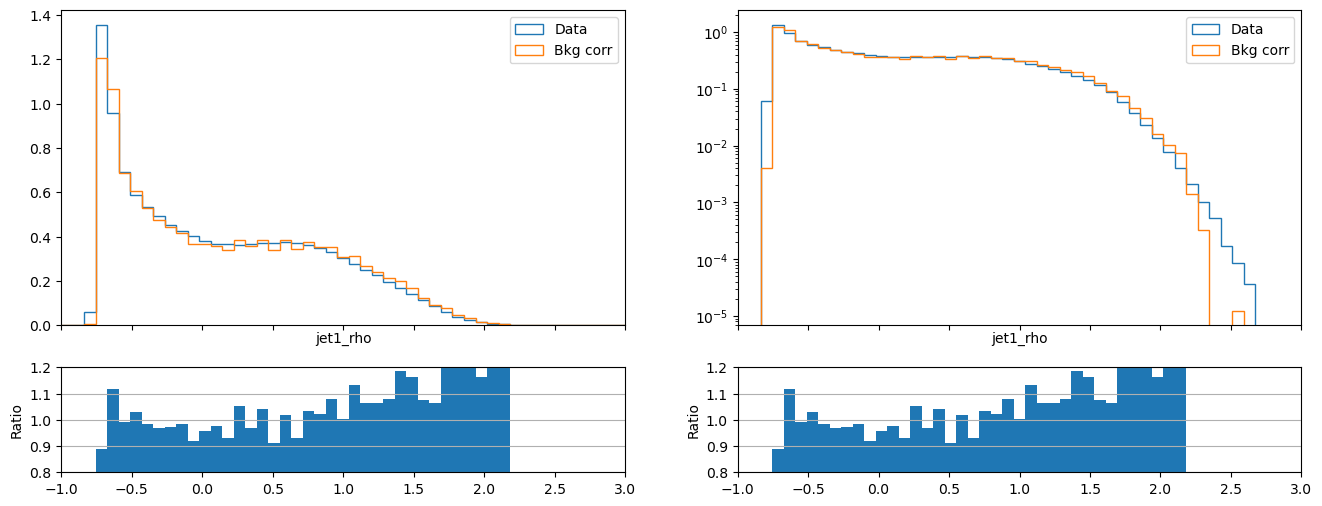

In [20]:
for v in variables:
    plt.subplots(figsize=(16,6),nrows=2,ncols=2,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    plt.subplot(221)
    h1,bins,_ = plt.hist(data[v],bins=np.linspace(-1,3,50),histtype='step',density=True,label='Data')
    h2,bins,_ = plt.hist(bkg_corr[v],bins=bins,histtype='step',density=True,label='Bkg corr')
    plt.legend()
    plt.xlabel(v)
    plt.subplot(223)
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    plt.bar(x=c,height=h2/h1,width=w,align='center')
    plt.ylim([0.8,1.2])
    plt.xlim([-1,3])
    plt.yticks(np.arange(0.8,1.3,0.1))
    plt.grid(axis='y')
    plt.ylabel("Ratio")
    plt.subplot(222)
    h1,bins,_ = plt.hist(data[v],bins=bins,histtype='step',density=True,label='Data')
    h2,bins,_ = plt.hist(bkg_corr[v],bins=bins,histtype='step',density=True,label='Bkg corr')
    plt.yscale('log')
    plt.legend()
    plt.xlabel(v)
    plt.subplot(224)
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    plt.bar(x=c,height=h2/h1,width=w,align='center')
    plt.ylim([0.8,1.2])
    plt.xlim([-1,3])
    plt.yticks(np.arange(0.8,1.3,0.1))
    plt.grid(axis='y')
    plt.ylabel("Ratio")